# Projet 1 - Analyse des observations d'OVNI (1949-2014)
ABDELLOU-GENESTIER Renaud LAFARGE Baptiste
## 1. Compréhension et présentation des données

### Présentation générale
Ce projet a pour objectif de mettre en œuvre un pipeline complet d'analyse de données à partir d'un jeu de données recensant plus de 80 000 apparitions d'OVNI. L'étude couvre la période de 1949 à 2014 et permet d'explorer les tendances temporelles, géographiques et morphologiques de ces phénomènes.

### Description des variables principales
- **datetime** : Date et heure de l'événement.
- **city / state / country** : Localisation de l'observation.
- **shape** : Forme de l'OVNI (cercle, lumière, triangle, etc.).
- **duration (seconds)** : Durée de l'observation normalisée en secondes.
- **comments** : Description textuelle courte de l'observation.
- **date posted** : Date à laquelle le rapport a été publié sur le site.
- **latitude / longitude** : Coordonnées géographiques.

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import html
import re

df = pd.read_csv('ufo.csv', low_memory=False)
df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,2004-04-27,29.8830556,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,2005-12-16,29.38421,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,2008-01-21,53.2,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,2004-01-17,28.9783333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,2004-01-22,21.4180556,-157.803611


### Identification des problèmes de qualité (Diagnostic)
Avant de nettoyer les données, nous identifions les types de données, les valeurs manquantes et les éventuelles incohérences.

In [5]:
print("--- Informations générales ---")
df.info()

print("\n--- Valeurs manquantes ---")
print(df.isnull().sum())

print(f"\n--- Nombre de doublons : {df.duplicated().sum()} ---")

print("\n--- Statistiques sur les durées (secondes) ---")
print(df['duration (seconds)'].describe())

print("\n--- Aperçu du format datetime ---")
print(df['datetime'].head())


--- Informations générales ---
<class 'pandas.DataFrame'>
RangeIndex: 80332 entries, 0 to 80331
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              80332 non-null  str    
 1   city                  80332 non-null  str    
 2   state                 74535 non-null  str    
 3   country               70662 non-null  str    
 4   shape                 78400 non-null  str    
 5   duration (seconds)    80332 non-null  str    
 6   duration (hours/min)  80332 non-null  str    
 7   comments              80317 non-null  str    
 8   date posted           80332 non-null  str    
 9   latitude              80332 non-null  str    
 10  longitude             80332 non-null  float64
dtypes: float64(1), str(10)
memory usage: 6.7 MB

--- Valeurs manquantes ---
datetime                   0
city                       0
state                   5797
country                 9670
shape          

**Observations initiales :**
1. **Valeurs manquantes** : Les colonnes `shape`, `state` et `country` présentent des manques significatifs.
2. **Types de données** : La colonne `datetime` est chargée comme un objet (chaîne) et doit être convertie pour l'analyse temporelle.
3. **Incohérences** : La colonne `duration (seconds)` contient probablement des valeurs aberrantes (max très élevé) ou des formats mixtes.
4. **Localisation** : `latitude` est parfois stockée sous un mauvais type.

## 2. Nettoyage des données

Avant d'analyser les données, on va s'assurer que le jeu de données est propre avec des données cohérentes.

In [6]:
df["state"] = df["state"].fillna("Unknown")
print(df['state'].head())

0         tx
1         tx
2    Unknown
3         tx
4         hi
Name: state, dtype: str


In [7]:
def format_duration(seconds_str):
    try:
        s = str(seconds_str).strip().replace('`','')
        total_seconds = float(s)
        
        if total_seconds >= 3600:
            hours = int(total_seconds // 3600)
            minutes = int((total_seconds % 3600) // 60)
            return f"{hours}h{minutes:02d}"
        elif total_seconds >= 60:
            minutes = int(total_seconds // 60)
            return f"{minutes}m"
        else:
            decimal_part = total_seconds - int(total_seconds)
            seconds = int(total_seconds) + 1 if decimal_part > 0.5 else int(total_seconds)
            return f"{seconds}s"
    except:
        return np.nan

df['duration (hours/min)'] = df['duration (seconds)'].apply(format_duration)
print(df[['duration (seconds)', 'duration (hours/min)']].head(10))

  duration (seconds) duration (hours/min)
0               2700                  45m
1               7200                 2h00
2                 20                  20s
3                 20                  20s
4                900                  15m
5                300                   5m
6                180                   3m
7               1200                  20m
8                180                   3m
9                120                   2m


In [8]:
df['shape'] = df['shape'].replace('unknown', np.nan)
df['shape'] = df['shape'].replace(r'^\s*$', np.nan, regex=True)
print(f"Nombre de valeurs manquantes dans 'shape' : {df['shape'].isna().sum()}")

Nombre de valeurs manquantes dans 'shape' : 7516


In [9]:
from rapidfuzz import fuzz, process
import geonamescache

gc = geonamescache.GeonamesCache()
cities_data = gc.get_cities()
reference_dict = {}
for c_id, info in cities_data.items():
    name_low = info['name'].lower()
    if name_low not in reference_dict or info['population'] > reference_dict[name_low][1]:
        reference_dict[name_low] = (info['name'], info['population'])

clean_reference_dict = {k: v[0] for k, v in reference_dict.items()}
reference_list = list(clean_reference_dict.keys())
noise_regex = re.compile(r'\b(afb|nas|station|county|airport|base|field|uk|usa|canada)\b', re.IGNORECASE)

def final_clean_city(name):
    if pd.isna(name): return np.nan
    name = html.unescape(str(name)).lower()
    name = re.split(r'/|\band\b|\(', name)[0]
    name = noise_regex.sub('', name)
    name = name.replace('?', '').strip()
    if not name or any(char.isdigit() for char in name): return np.nan
    result = process.extractOne(name, reference_list, scorer=fuzz.token_set_ratio, score_cutoff=100)
    if result: return clean_reference_dict[result[0]]
    return name

unique_cities = df['city'].unique()
mapping = {city: final_clean_city(city) for city in unique_cities}
df['city'] = df['city'].map(mapping)

In [10]:
connexion = sqlite3.connect("ufo.db")
df.to_sql("ufo", connexion, if_exists="replace", index=False)

80332

## 3. Analyse Exploratoire des Données

Cette section explore les tendances temporelles récentes, la distribution statistique des durées d'observation et les thématiques récurrentes dans les témoignages.

### 3.b Analyse temporelle spécifique (2000 - 2014)
Evolution du nombre d'observations annuelles sur les 15 dernières années du jeu de données.

In [5]:
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df_2000 = df[df['datetime'].dt.year >= 2000].copy()
df_2000['year'] = df_2000['datetime'].dt.year.astype(int)
yearly_counts = df_2000['year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=yearly_counts.index, y=yearly_counts.values, palette="viridis")
plt.title("Nombre d'observations d'OVNI par an (2000-2014)", fontsize=14)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'observations", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

NameError: name 'df' is not defined

Quelque chose que l'on peut également remarqué est l'augmentation drastique après 2010 jusqu'a 2013. Certains évènements peuvent l'expliquer, premièrement on peut commencer par les avancées technologiques toujours plus présente au fils des ans, mais surtout ce qui fait que cela redescends en 2014 comparé a avant sont deux films qui ont énormément fonctionner au box office, en 2011 on a cowboy versus envahisseurs, et en 2012 on a le film Prometheus qui fait parti de la saga de film alien une saga mondialement connue ayant un grand impact dans la pop culture.

### Analyse statistique de la durée
Distribution des durées d'observation. L'utilisation d'une échelle logarithmique est nécessaire en raison de la présence de valeurs extrêmes (outliers).

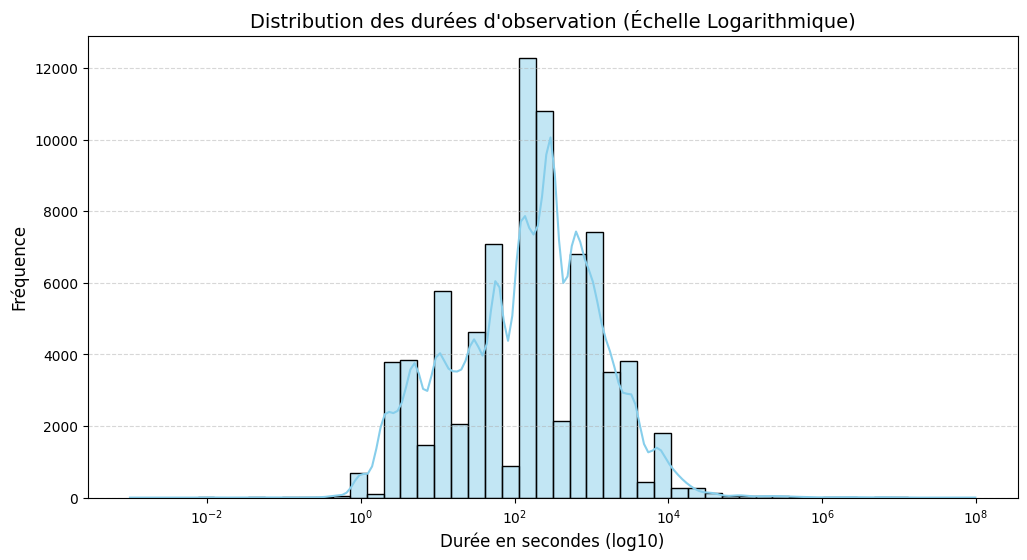

In [ ]:
df['duration (seconds)'] = pd.to_numeric(df['duration (seconds)'].astype(str).str.replace('`',''), errors='coerce')
duration_data = df[df['duration (seconds)'] > 0]['duration (seconds)']

plt.figure(figsize=(12, 6))
sns.histplot(duration_data, bins=50, kde=True, log_scale=True, color="skyblue")
plt.title("Distribution des durées d'observation (Échelle Logarithmique)", fontsize=14)
plt.xlabel("Durée en secondes (log10)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

On peut ainsi voir que la plupart des gens voient un ovni environ log10(10²) = 2 secondes, ainsi le temps d'observation est très courts. 

### Analyse statistique de la temporalité
Distribution de l'heure d'observation. On prend en comptes toutes les années présente on classe avec la colonne dateTime qui nous donne l'heure au format HH:MM:SS

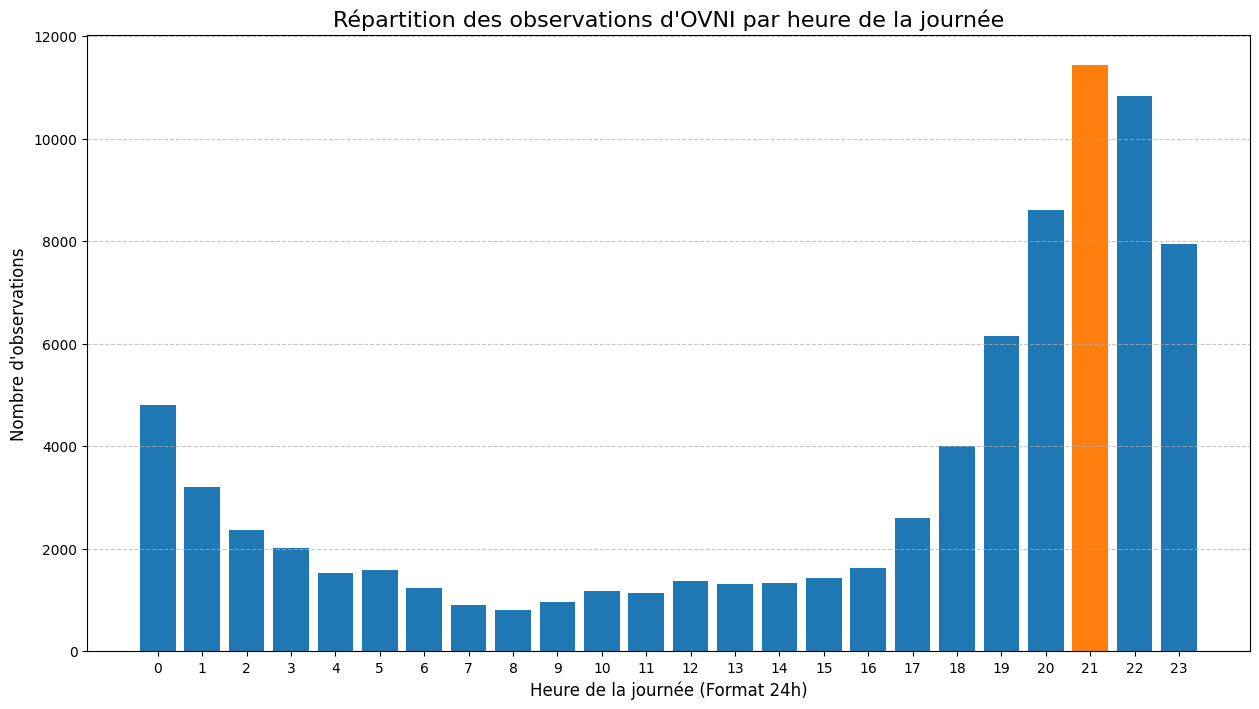

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('./ufo.db')
# Requête SQL pour extraire l'heure (00-23) et compter les observations
query = """
SELECT strftime('%H', datetime) as hour, COUNT(*) as count
FROM ufo
WHERE datetime IS NOT NULL
GROUP BY hour
"""
df_sql = pd.read_sql_query(query, conn)
conn.close()
df_sql['hour'] = df_sql['hour'].astype(int)
sightings_by_hour = df_sql.set_index('hour')['count']
all_hours = pd.RangeIndex(start=0, stop=24)
sightings_by_hour = sightings_by_hour.reindex(all_hours, fill_value=0)
plt.figure(figsize=(15, 8))
# En orange la valeur maximale pour la mettre en valeur
max_hour = sightings_by_hour.idxmax()
colors = ['#ff7f0e' if hour == max_hour else '#1f77b4' for hour in sightings_by_hour.index]

plt.bar(sightings_by_hour.index, sightings_by_hour.values, color=colors)

plt.title("Répartition des observations d'OVNI par heure de la journée", fontsize=16)
plt.xlabel("Heure de la journée (Format 24h)", fontsize=12)
plt.ylabel("Nombre d'observations", fontsize=12)
plt.xticks(sightings_by_hour.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)



Le graphe révèle que l'observation d'ovni se concentre durant la soiré et la nuit . Ce phénomène peut s'expliquer par l'obscurité qui limite les repères visuels, poussant le cerveau à interpréter des stimuli lumineux ou sonores de manière erronée. Cette tendance est renforcée par l'imaginaire collectif qui associ l'inconnu et le mystère à l'environnement nocturne.

### Analyse textuelle des commentaires
Nuage de mots (Word Cloud) illustrant les termes les plus fréquents utilisés par les témoins pour décrire leurs observations.

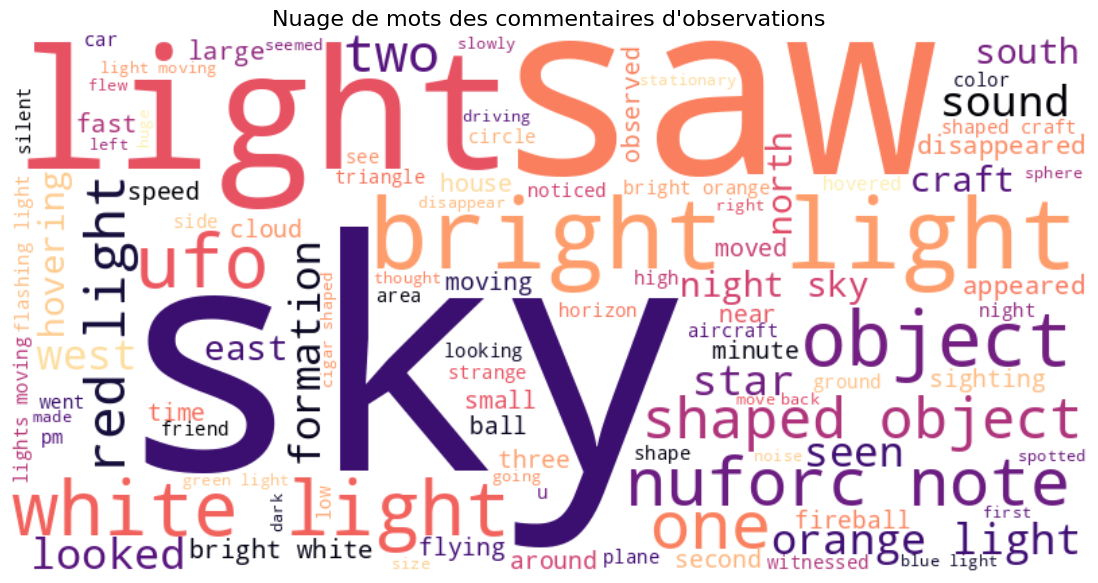

In [ ]:
from wordcloud import WordCloud

def clean_comment(text):
    if pd.isna(text): return ""
    text = html.unescape(str(text))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

all_comments = " ".join(df['comments'].apply(clean_comment))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma', max_words=100).generate(all_comments)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nuage de mots des commentaires d'observations", fontsize=16)
plt.show()

On peut ici voir que certains mots reviennent bien plus que d'autre, on peut analyser tout ça. Pour commencer, la majorité des gens voient une lumière dans le ciel, ce qu'on peut voir via les mots "sky", "light", et "saw". On peut également remarqué des choses un peu plus originale, comme une "lumière blue", ou encore du silence, du bruit, une "boule de feu", ou encore un lien avec l'amitié ? On peut par dessus tout voir avec ce nuage de points que énormément de situations différentes se produisent, ainsi c'est difficile de dire qu'il y aurait une situation "particulière" qui pourrait paraître "réaliste" car il existe énormément de situations différentes, et que la situation la plus documenté, celle d'une lumière dans le ciel, est très vague. 

### Analyse : Impact culturel et géopolitique

Le film E.T. de Steven Spielberg sorti en 1982 a-t-il une incidence sur le nombre d'OVNI vus et référencés ?

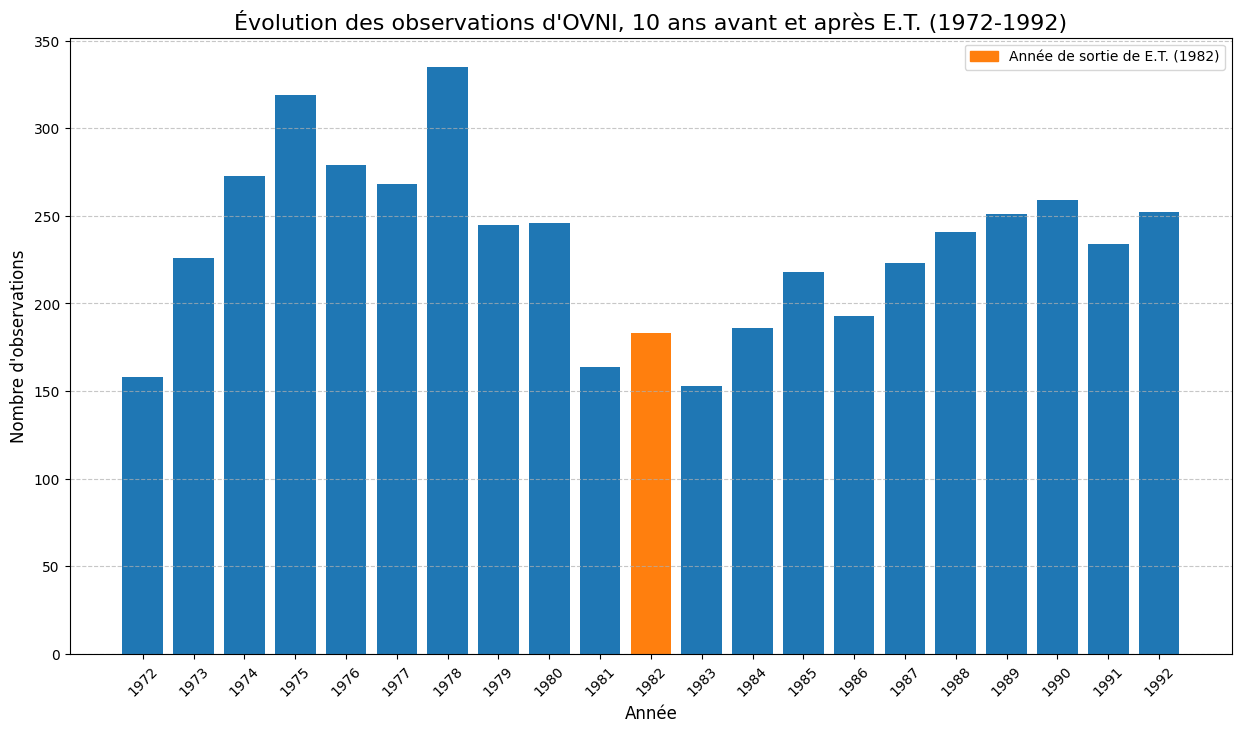

In [ ]:
import matplotlib.patches as mpatches
conn = sqlite3.connect('ufo.db')
query = """
SELECT strftime('%Y', datetime) as year, COUNT(*) as count
FROM ufo
WHERE strftime('%Y', datetime) BETWEEN '1972' AND '1992'
GROUP BY year
"""
df_sql = pd.read_sql_query(query, conn)
conn.close()
df_sql['year'] = df_sql['year'].astype(int)
sightings_by_year = df_sql.set_index('year')['count']
all_years = pd.RangeIndex(start=1972, stop=1993)
sightings_by_year = sightings_by_year.reindex(all_years, fill_value=0)

plt.figure(figsize=(15, 8))
colors = ['#ff7f0e' if year == 1982 else '#1f77b4' for year in sightings_by_year.index]
bars = plt.bar(sightings_by_year.index, sightings_by_year.values, color=colors)
plt.title("Évolution des observations d'OVNI, 10 ans avant et aprè" \
"s E.T. (1972-1992)", fontsize=16)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'observations", fontsize=12)
plt.xticks(sightings_by_year.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
orange_patch = mpatches.Patch(color='#ff7f0e', label='Année de sortie de E.T. (1982)')
plt.legend(handles=[orange_patch])
plt.show()

On voit que le film E.T n'a pas vraiment d'impact sur l'observation d'ovni il y en autant voir plus avant la diffusion du film qu'après est même sur l'année de sortie on n'observe pas plus d'obeservation que d'autre année comme 1975 et 1978


Dans un second temps, on peut essayer d'observer si la guerre froide aurait pu avoir de potentiels incidents sur l'observation d'Ovni à cause d'expériences scientifiques secrètes ou encore de nouveauté technologique inconnue du grand publique. On rappelle ici que la guerre froide à eu lieu entre 1947 et 1991  (Effondrement du bloc de l'est)

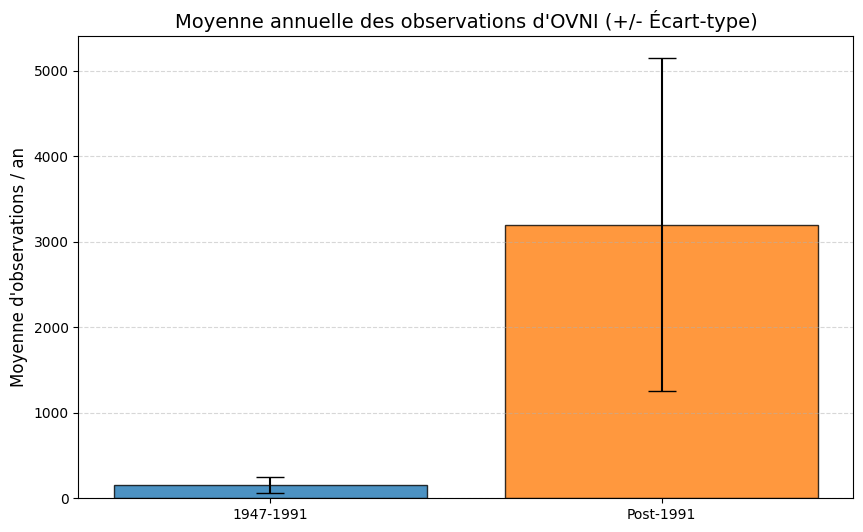

In [ ]:
query = """
WITH sightings_per_year AS (
    SELECT 
        CAST(strftime('%Y', datetime) AS INTEGER) as year,
        COUNT(*) as count
    FROM ufo
    WHERE year >= 1947
    GROUP BY year
),
period_stats AS (
    SELECT
        CASE
            WHEN year BETWEEN 1947 AND 1991 THEN '1947-1991'
            ELSE 'Post-1991'
        END AS periode_temporelle,
        count
    FROM sightings_per_year
)
SELECT
    periode_temporelle,
    SUM(count) AS total_observations,
    COUNT(*) AS nombre_annees_couvertes,
    ROUND(AVG(count), 2) AS moyenne_par_an,
    ROUND(SQRT(AVG(count * count) - AVG(count) * AVG(count)), 2) AS ecart_type_par_an
FROM
    period_stats
GROUP BY
    1
ORDER BY
    periode_temporelle;
"""
with sqlite3.connect('ufo.db') as conn:
    df_guerra = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))
bars = plt.bar(df_guerra['periode_temporelle'], df_guerra['moyenne_par_an'], 
               yerr=df_guerra['ecart_type_par_an'], capsize=10,
               color=['#1f77b4', '#ff7f0e'], edgecolor='black', alpha=0.8)
plt.title('Moyenne annuelle des observations d\'OVNI (+/- Écart-type)', fontsize=14)
plt.ylabel('Moyenne d\'observations / an', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Avec ce graphique, on peut facilement remarqué que la moyenne annuelle d'observation a drastiquement augmenté après les années guerre froide, ce qui peut paraître très contradictoire par rapport a la problématique que nous avons posé plus tôt. En revanche, cela peut être expliqué par plusieurs choses, premièrement, on peut l'expliquer par le fait que les observations n'étaient pas forcémment autant documentée pendant les années guerre froide par rapport à après, justement pour une question de stratégie, de secret d'états etc ... On pourrait également l'expliquer par le fait la pop culture s'est avancée avec le temps, et que les gens, grâce aux séries, films, et tout ce qui concerne le domaine de l'alien et du spatiel, se seraient mis à voir de plus en plus d'Ovni suitent à ce qu'ils ont vu dans leurs petits écrans.

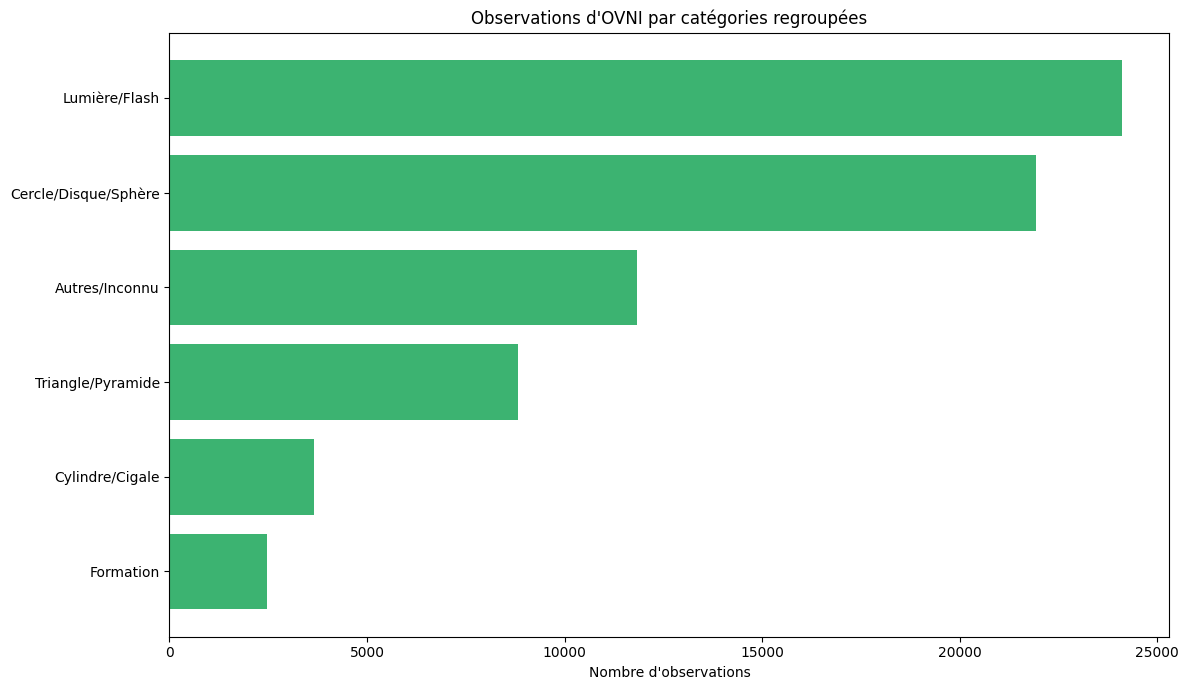

In [ ]:
conn = sqlite3.connect('ufo.db')
query = """
SELECT forme, COUNT(*) as total
FROM (
    SELECT
        CASE
            WHEN lower(shape) IN ('circle', 'disk', 'oval', 'round', 'sphere') THEN 'Cercle/Disque/Sphère'
            WHEN lower(shape) IN ('cylinder', 'cigar', 'cone') THEN 'Cylindre/Cigale'
            WHEN lower(shape) IN ('light', 'flash', 'fireball', 'flare') THEN 'Lumière/Flash'
            WHEN lower(shape) IN ('triangle', 'chevron', 'pyramid') THEN 'Triangle/Pyramide'
            WHEN lower(shape) IN ('formation') THEN 'Formation'
            ELSE 'Autres/Inconnu'
        END AS forme
    FROM ufo
    WHERE shape IS NOT NULL AND shape != ''
)
GROUP BY forme
ORDER BY total DESC;
"""
df_shapes = pd.read_sql_query(query, conn)
plt.figure(figsize=(12, 7))
plt.barh(df_shapes['forme'], df_shapes['total'], color='mediumseagreen')
plt.xlabel('Nombre d\'observations')
plt.title('Observations d\'OVNI par catégories regroupées')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
conn.close()

Avec ce graphique, on peut observer que la plupart des gens voient en une lumière vive ou des flashs de lumière une potentielle présence extraterrestres. Ce genre de vision peut facilement s'expliquer de manière scientifique, que ce soit par des hallucinations, des aberrations cinétiques etc ... On peut donc en conclure que beaucoup de gens aiment/veulent croire aux Ovnis sur la base de flashs/vagues lumières.

Notre dataset se base au ETAT-UNIS regardont les états avec le plus d'ovni observer et pourquoi 

C:\Users\babla\AppData\Local\Temp\ipykernel_13276\143603925.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='state', data=df_states, palette="viridis")


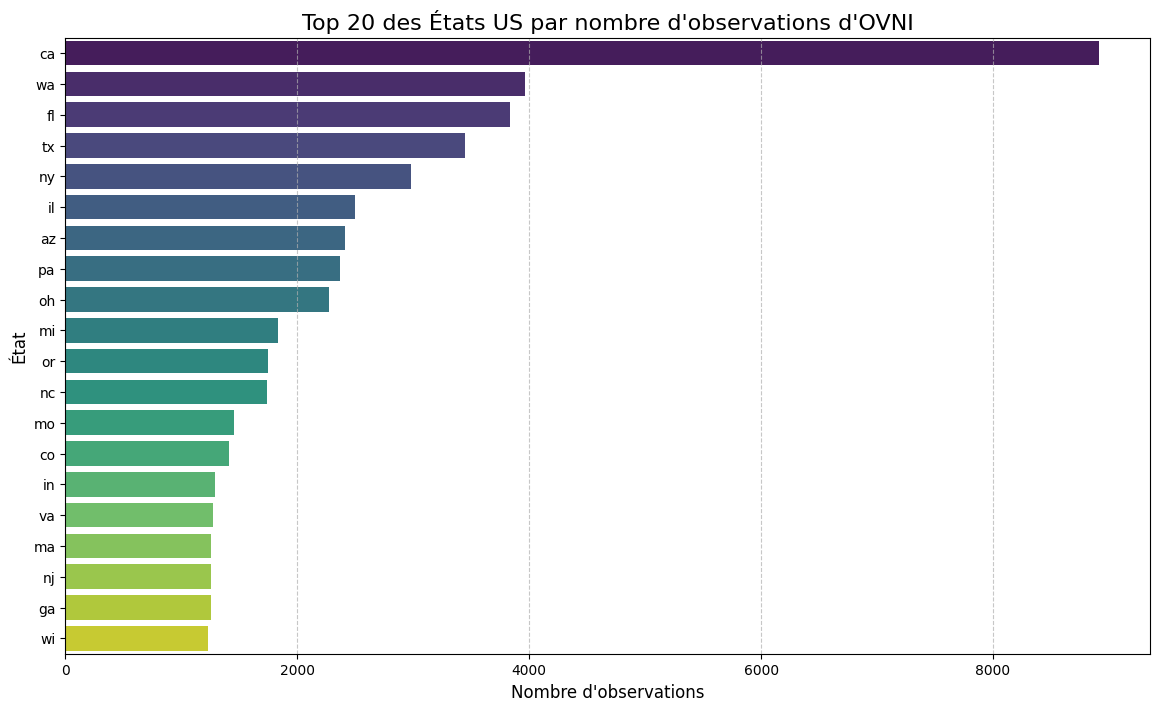

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Connexion à la base de données
conn = sqlite3.connect('ufo.db')
# Requête pour obtenir le compte par état (uniquement pour les USA)
query = """
SELECT state, COUNT(*) as count
FROM ufo
WHERE country = 'us' AND state != 'Unknown'
GROUP BY state
ORDER BY count DESC
LIMIT 20
"""
df_states = pd.read_sql_query(query, conn)
conn.close()

# Création du graphique
plt.figure(figsize=(14, 8))
sns.barplot(x='count', y='state', data=df_states, palette="viridis")
plt.title("Top 20 des États US par nombre d'observations d'OVNI", fontsize=16)
plt.xlabel("Nombre d'observations", fontsize=12)
plt.ylabel("État", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

On observe que la californie est l'état avec largement le plus d'observation. Un résultat qui s'explique. Tout d'abord c'est l'état le plus peuple des Etat-Unis avec 39,5 Millions d'habitant. Mais ce n'est pas tout il y a une forte activité aérospatiale et militaire. On peut ajouter les conditions météo et géopragphiques dans le sud de la Californie et les zone désertiques, donne une excellente visibilté. Un ciel clair facilite l'observation d'objets qui peuvent être interpreter comme des ovnis. Enfin HollyWood se trouve en californie on peut supposer que la culuture Science Fiction et ancrée localement. la population est "conditionnée à lever les yeux au ciel et interpréter l'inconnue sous l'angle extraterrestre. 

### Conclusion

Conclusion de l'étude sur les observations d'OVNI


  L'étude menée à travers ce notebook permet de tirer plusieurs conclusions majeures sur la nature et la répartition des phénomènes rapportés :


   1. Prédominance du facteur humain et psychologique :
       * La majorité des observations ont lieu le soir et la nuit. L'obscurité, en limitant les repères visuels, favorise les erreurs
         d'interprétation de stimuli lumineux (satellites, avions, phénomènes météo).
       * L'analyse textuelle montre que les termes les plus fréquents sont très vagues ("light", "sky", "saw"), suggérant que les témoins
         rapportent souvent des stimuli visuels indéterminés plutôt que des objets structurés.


   2. Influence majeure de la Pop Culture :
       * On observe une augmentation drastique des signalements entre 2010 et 2013, corrélée à la sortie de films de science-fiction majeurs
         (Prometheus, Cowboys & Envahisseurs).
       * Contrairement aux attentes, la Guerre Froide n'a pas généré plus de signalements que la période suivante. L'explosion des rapports
         après 1991 s'explique probablement par la démocratisation d'Internet, facilitant le partage des témoignages, et par l'ancrage profond
         de l'imaginaire "alien" dans la culture moderne.


   3. Facteurs géographiques et démographiques :
       * La Californie est l'épicentre des observations aux États-Unis. Ce pic s'explique par une combinaison de facteurs : une population     
         élevée, un ciel clair dans les zones désertiques (meilleure visibilité), une forte activité militaire/aérospatiale et l'influence     
         culturelle d'Hollywood.


   4. Nature éphémère des phénomènes :
       * L'analyse statistique montre que la plupart des observations sont extrêmement courtes (quelques secondes), ce qui renforce l'idée de
         méprises rapides de phénomènes fugitifs.


  En résumé, bien que le jeu de données soit vaste, les tendances révélées pointent davantage vers un phénomène socioculturel et psychologique 
  que vers une preuve d'activité extraterrestre. Les observations sont intrinsèquement liées à la visibilité nocturne, à la densité de
  population et à l'influence des médias de masse.
